# PageRank Implementation in Numpy

In [1]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

## WEB - Modelling - Main Data Structure

Firistly, we will model of a small modelled web of three Pages: A,B and C. We will build a simple 3-page cyce (A $\rightarrow$ B $\rightarrow$ C $\rightarrow$ A) and an array that reprsentes the link structure (Adjacency Matirces). This will be our 3-page test graph to verify the PageRank logic later. 

In [2]:
#3-Page cyclic Web and .
# Build Adjacency matrix: A[i,j] = 1 if page j links to page i
A_test = np.array([
    [0,0,1], # Row (0): Page A is connected from page C 
    [1,0,0], # Row (1): Page B is connected from page A
    [0,1,0] # Row (2): Page C is connected from page B
])

A_test = np.array(A_test, dtype = float)

pages_test = ['A', 'B', 'C']

print("3-page Web") 
print("\nAdjancency Matrix Visualization:")
print("    A  B  C")
for i, row_label in enumerate (["A","B","C"]): #Dispay the matrix
    print(f"{row_label}  {A_test[i]}")

print("\n Link Structure Verification")
for j, page in enumerate (["A","B","C"]):
    outlinks = np.where(A_test[:,j]== 1)[0]
    target_labels = [["A","B","C"][k] for k in outlinks]
    print (f"Page {page} links to {target_labels}")

3-page Web

Adjancency Matrix Visualization:
    A  B  C
A  [0. 0. 1.]
B  [1. 0. 0.]
C  [0. 1. 0.]

 Link Structure Verification
Page A links to ['B']
Page B links to ['C']
Page C links to ['A']


Now we will create the full web on which we will test the PageRank algorithm. We will model a 8-page web with:
* Assymetric Structure: Pages have different numbers of in/outlinks
* Spyder Trap: Pages F and G for an isolated cycle
* Dangling Node: Page H has no outgoing links

Graph Structure:

Main Cluster  (Pages A-E): <br>
A $\rightarrow$ B, C     (Page A links to B and C) <br>
B $\rightarrow$ C, D     (Page B links to C and D) <br>
C $\rightarrow$ A, D     (Page C links to A and D) <br>
D $\rightarrow$ A, E, H  (Page D links to A, E, and H) <br>
E $\rightarrow$ F        (Page E bridges to spider trap) <br>

Spider Trap (Pages F-G): <br>
F ↔ G        (F and G link to each other, isolated cycle)

Dangling Node: <br>
H → (none)   (Page H is a dead end - no outlinks)
```

**Visual representation:**
```
        ┌──→ B ───→ D ──┐
        │    ↓      ↑   │
    A ──┤    C ─────┘   ├──→ E ──→ F ↔ G
        │    ↑          │      (spider trap)
        └────┘          │
                        └──→ H (dangling)



In [3]:
#8-Page Complex Web

np.set_printoptions(precision=4, suppress=True) #floating numbers have 4 digits after .0 and no scientific format 10e-2

# Pages: A=0, B=1, C=2, D=3, E=4, F=5, G=6, H=7
#Page Labels
page_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

A_web = np.array([
    #A,B,C,D,E,F,G,H
    [0,0,1,1,0,0,0,0], # A receives links from C, D
    [1,0,0,0,0,0,0,0], # B receives links from A
    [1,1,0,0,0,0,0,0], # C receives links from B, A
    [0,1,1,0,0,0,0,0], # D receives links from B, C
    [0,0,0,1,0,0,0,0], # E receives links from D
    [0,0,0,0,1,0,1,0], # F receives links from E, G
    [0,0,0,0,0,1,0,0], # G receives links from F (
    [0,0,0,1,0,0,0,0] # H receives links from D
])

A_web = np.array (A_web, dtype = 'float')

print("8-Page Web Adjacency Matrix:")
print("    ", "  ".join(page_labels))
for i, label in enumerate(page_labels):
    print(f"{label}   {A_web[i]}")

8-Page Web Adjacency Matrix:
     A  B  C  D  E  F  G  H
A   [0. 0. 1. 1. 0. 0. 0. 0.]
B   [1. 0. 0. 0. 0. 0. 0. 0.]
C   [1. 1. 0. 0. 0. 0. 0. 0.]
D   [0. 1. 1. 0. 0. 0. 0. 0.]
E   [0. 0. 0. 1. 0. 0. 0. 0.]
F   [0. 0. 0. 0. 1. 0. 1. 0.]
G   [0. 0. 0. 0. 0. 1. 0. 0.]
H   [0. 0. 0. 1. 0. 0. 0. 0.]


In [4]:
#Spider Traps & Dangling Nodes

#Detailed Link Structure
for j, page in enumerate(page_labels):
    outlinks_indices = np.where(A_web[:,j]== 1)[0]
    if len(outlinks_indices)> 0 :
        outlinks_labels = [page_labels[k] for k in outlinks_indices]
        print(f"Page {page} -> {list(outlinks_labels)})")
    else:
        print(f"Page {page} -> None (dangling_node)\n")
        

#Identify dangling nodes (nodes without output links)
out_degrees = A_web.sum(axis=0)
dangling_nodes = np.where(out_degrees== 0)[0]
dangling_labels = [page_labels[i] for i in dangling_nodes]

print(f"Dangling Nodes:{dangling_labels} - no outgoing links\n")

Page A -> ['B', 'C'])
Page B -> ['C', 'D'])
Page C -> ['A', 'D'])
Page D -> ['A', 'E', 'H'])
Page E -> ['F'])
Page F -> ['G'])
Page G -> ['F'])
Page H -> None (dangling_node)

Dangling Nodes:['H'] - no outgoing links



## Transition Matrix

In this section we will create the Transition Matrix Conversion Function. The goal of this section is to transform the adjacency matrix into a column-stockastic transition matrix. In such matrix the sum of all columns is equal to 1. This function must be able to handle the dangling nodes in the web. 

Mathematical concept: If page $j$ has $k$ outlinks, each link gets probability $\frac{1}{k}$. For dangling nodes, we assign uniform probability to all pages.

The applied approach is desscribed below: 
1. First, we will convert convert an adjacency matrix to a column-stochastic transition matrix. Enty $M[i,j]$ is the probability of jumping from page $j$ to page $i$. In this step we will not assume the presence of dangling nodes (all columns have at least one 1).
2. Zero Division Handling - introduce dangling nodes. The applied approach in this step is to apply uniform distribution to all zero columns. This assigns an equal probability to come to the dangling node from any page.

In [5]:
### Column-Stochastic Matrix
out_degree = A_test.sum(axis=0) #calculate the sum of each column
M_test= A_test / out_degree #Normalize: divide each column by its sum -> making each column a probability distribution.

M_test

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [6]:
def build_transition_matrix_v1(adjacency_matrix):
    out_degree = adjacency_matrix.sum(axis=0)
    transition_matrix = adjacency_matrix / out_degree

    return transition_matrix

M_test_v1 = build_transition_matrix_v1(A_test)

#Print matrix
print(f"Result: Transition Matrix \n {M_test_v1}\n")

#Check taht columns sums to 1
column_sums = M_test_v1.sum(axis=0)
print(f"Column sumns: {column_sums}")
print (f"All columns sum to 1?: {np.allclose(column_sums,1.0)}")


Result: Transition Matrix 
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]

Column sumns: [1. 1. 1.]
All columns sum to 1?: True


In [7]:
def build_transition_matrix_v2 (adjacent_matrix):
    mat_copy = adjacent_matrix.copy()  # Copy the Adjacenet Matrix
    page_count = mat_copy.shape[0] # count the number of pages

    out_degree = mat_copy.sum(axis = 0) # Find the column sum 
    dangling_nodes = (out_degree == 0) #Check if any column sum = 0

    if np.any(dangling_nodes):     
        mat_copy[:, dangling_nodes] = 1.0 / page_count # Set entire column to 1/n (uniform distribution)
        out_degree[dangling_nodes] = 1.0  

    tran_mat = mat_copy / out_degree

    return tran_mat

In [8]:
#Test to 3-page cycle (no-dangling nodes) 
m_test = build_transition_matrix_v2(A_test)

print("Transition Matrix m_test: \n")
print(f"{m_test} \n")
print(f" Column sums: {m_test.sum(axis=0)}")
print()

Transition Matrix m_test: 

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]] 

 Column sums: [1. 1. 1.]



In [9]:
#Test to 8-page cycle (dangling nodes)
m_web = build_transition_matrix_v2(A_web)

print("Transition Matrix m_web:\n")
print(f"{m_web}\n")
print(f"Column sums: {m_web.sum(axis=0)}\n")

Transition Matrix m_web:

[[0.     0.     0.5    0.3333 0.     0.     0.     0.125 ]
 [0.5    0.     0.     0.     0.     0.     0.     0.125 ]
 [0.5    0.5    0.     0.     0.     0.     0.     0.125 ]
 [0.     0.5    0.5    0.     0.     0.     0.     0.125 ]
 [0.     0.     0.     0.3333 0.     0.     0.     0.125 ]
 [0.     0.     0.     0.     1.     0.     1.     0.125 ]
 [0.     0.     0.     0.     0.     1.     0.     0.125 ]
 [0.     0.     0.     0.3333 0.     0.     0.     0.125 ]]

Column sums: [1. 1. 1. 1. 1. 1. 1. 1.]



In [10]:
### Add Assertation to guarantee all column sum is exactly 1.0
def build_transition_matrix (adjacent_matrix):
    mat_copy = adjacent_matrix.copy()  # Copy the Adjacenet Matrix
    page_count = mat_copy.shape[0] # count the number of pages

    out_degree = mat_copy.sum(axis = 0) # Find the column sum 
    dangling_nodes = (out_degree == 0) #Check if any column sum = 0

    if np.any(dangling_nodes):     
        mat_copy[:, dangling_nodes] = 1.0 / page_count # Set entire column to 1/n (uniform distribution)
        out_degree[dangling_nodes] = 1.0  

    tran_mat = mat_copy / out_degree

    #Assert column-stochastic property
    assert np.allclose(tran_mat.sum(axis=0),1.0), "Matrix is not column stochastic"
    
    return tran_mat

In [11]:
#Test to 8-page cycle (dangling nodes)
m_web = build_transition_matrix(A_web)

print("Transition Matrix m_web:\n")
print(f"{m_web}\n")
print(f"Column sums: {m_web.sum(axis=0)}\n")

Transition Matrix m_web:

[[0.     0.     0.5    0.3333 0.     0.     0.     0.125 ]
 [0.5    0.     0.     0.     0.     0.     0.     0.125 ]
 [0.5    0.5    0.     0.     0.     0.     0.     0.125 ]
 [0.     0.5    0.5    0.     0.     0.     0.     0.125 ]
 [0.     0.     0.     0.3333 0.     0.     0.     0.125 ]
 [0.     0.     0.     0.     1.     0.     1.     0.125 ]
 [0.     0.     0.     0.     0.     1.     0.     0.125 ]
 [0.     0.     0.     0.3333 0.     0.     0.     0.125 ]]

Column sums: [1. 1. 1. 1. 1. 1. 1. 1.]



## Power Iteration


In this section we are going to compute the PageRank via repeated matrix multiplication and find the most "important" page in our modelled web network. This will be done by computing the "steady-state" eigenvector and plot its convergence. 

The applied approach is desscribed below: 
1. First, we will start with a uniform probability vector and simply multiply it by the matrix a fixed number of times
2. Second, we will track the difference between iterations using the L1 norm and stop when it falls below a treshold: $|v_{new} - v| \leq \varepsilon$ 
3. Visualize: We will store the error at each step and plot the exponentian decay.

### Uniform Probability Vector

In [12]:
# No check for convergence
m_test

page_count = m_test.shape[0] # get the number of pages

x = np.ones(page_count) / page_count # Intial Vector with Probabilities -> All pages start with equal probability to be visited 1 / Total pages 

num_iterations = 10 # how many times we multiply 

for k in range(num_iterations):
    x_new = m_test @ x
    
    if k % 3 == 0 or k == num_iterations - 1:
        print(f"Iterations{k+1}: {x_new}")
    
    x = x_new

print()

Iterations1: [0.3333 0.3333 0.3333]
Iterations4: [0.3333 0.3333 0.3333]
Iterations7: [0.3333 0.3333 0.3333]
Iterations10: [0.3333 0.3333 0.3333]



In [13]:
def pagerank_fixed_iterations (M, num_iterations = 10):
    page_count = M.shape[0]
    x = np.ones(page_count) / page_count

    for k in range(num_iterations):
        x_new = M @ x 
        x = x_new

        if k % 5 == 0 or k == num_iterations - 1:
            print(f"Iterations{k+1}: {x_new}")  
            
    return x 

In [14]:
#Test the functions
r_test = pagerank_fixed_iterations(m_test,10)

print (f"Final PageRank: {r_test}\n")
print (f"Sum: {r_test.sum():.4f}") # Expected Sum = 1.0

Iterations1: [0.3333 0.3333 0.3333]
Iterations6: [0.3333 0.3333 0.3333]
Iterations10: [0.3333 0.3333 0.3333]
Final PageRank: [0.3333 0.3333 0.3333]

Sum: 1.0000


### L1 Norm Convergence

Replace fixed iterations with convergence criterion. Track error at each step so we can plot it later.


In [15]:
def pagerank_with_convergence(M, epsilon= 1e-6, max_iterations = 50):

    page_count = M.shape[0]
    x = np.ones(page_count) / page_count

    error_history = []  #Store error on each step

    for iteration in range(max_iterations):
        x_new = M @ x 
        error = np.linalg.norm(x_new - x, ord = 1) #Compute L1 Norm of difference

        error_history.append(error)

        if iteration % 25 == 0:
            print (f"Iteration {iteration + 1}: error = {error:.2e}")

        if error < epsilon: 
            print(f"Converged in {iteration + 1} with final error = {error:.2e}\n")
            return x_new, error_history

        x = x_new #Update vector for new iteration

    return x, error_history

In [16]:
#Test the convergence function 

r_test_2, history_test = pagerank_with_convergence(m_web, 1e-6, 50)

print(f"Final PageRank: {r_test_2}")
print(f"Sum: {r_test_2.sum():.6f}") #Expected sum = 1
print(f"Total Iterations (# of Recorded Errors): {len(history_test)}")

Iteration 1: error = 3.75e-01
Iteration 26: error = 1.92e-01
Final PageRank: [0.0002 0.0001 0.0002 0.0002 0.0001 0.4523 0.5466 0.0001]
Sum: 1.000000
Total Iterations (# of Recorded Errors): 50


In [17]:
# Error Tracking and Visualizaiton
def plot_convergence (convergence_history, title = "Plot Convergence History"):

    fig = plt.figure(figsize=(10,6))
    iterations = range(1, len(convergence_history) + 1)
    plt.semilogy(iterations, convergence_history, 'b-',linewidth = 2) #Make a plot with log scaling on the y-axis

    plt.axhline(y = 1e-6, color = 'r', linestyle = '--', label = "Conv Treshold") #Add a horizontal line spanning the whole or fraction of the Axes.

    plt.xlabel('Iteration k')
    plt.ylabel('Abs Error')
    plt.title(title)
    plt.grid()
    plt.legend()

    #display the plot
    plt.show()

In [18]:
#Add damping function (from Issue #7 preview) and full 8-page test:
def add_damping(transition_matrix, damping_factor = 0.85):
    n = transition_matrix.shape[0] 
    d = damping_factor
    e = np.ones((n, n))
    
    m_prime = d * transition_matrix + ((1 - d) / n) * e # apply the damping factor to the transition matrix 
    column_sums = m_prime.sum(axis = 0)
    
    assert np.allclose(column_sums, 1.0), "Error: Damped matrix is not column-stochastic"
    print(f"Damping factor d = {d} applied successfully")
    
    return m_prime

In [19]:
# Build prime matrice
m_prime_test = add_damping(m_test, damping_factor = 0.85) # Build the M* matrix for A_test network 
m_prime_web = add_damping(m_web, damping_factor = 0.85) #Build the M* matrix for the A_web Network (complicated network) 

Damping factor d = 0.85 applied successfully
Damping factor d = 0.85 applied successfully


In [20]:
#Final function -> Compute PageRank using the Power Iteration method with Damping Factor!
def pagerank_power_iteration(m_prime, epsilon = 1e-6, max_iterations = 50):
    # Get the number of pages
    page_count = m_prime.shape[0]
    x = np.ones(page_count) / page_count
    
    error_history = [] # Storage for convergence error tracking
    
    # Main iteration loop
    for iteration in range(max_iterations):
        x_new = m_prime @ x
        error = np.linalg.norm(x_new - x, ord = 1)
        
        error_history.append(error)

        if iteration % 25 == 0:
            print (f"Iteration {iteration+1}: error = {error:.2e}")

        if error <= epsilon: 
            print(f"Converged in {iteration + 1} with final error = {error:.2e}\n")
            
            return x_new, error_history
            
        x = x_new # update vector
    
    return x, error_history

In [21]:
def plot_pagerank_scores(pagerank_vector, labels, title="PageRank Scores"):
    plt.figure(figsize=(10, 6))
    
    colors = plt.cm.viridis(pagerank_vector / pagerank_vector.max())
    bars = plt.bar(labels, pagerank_vector, color=colors, edgecolor='black', linewidth=1.5)
    
    for bar, value in zip(bars, pagerank_vector):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Labels and formatting
    plt.xlabel('Page', fontsize=12, fontweight='bold')
    plt.ylabel('PageRank Score', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylim(0, pagerank_vector.max() * 1.15)  # Add space for labels
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Iteration 1: error = 3.19e-01
Iteration 26: error = 2.81e-03

Page | PageRank Score | Percentage
------------------------------------------
  A  |    0.084104    |   8.41%
  B  |    0.059595    |   5.96%
  C  |    0.084924    |   8.49%
  D  |    0.085272    |   8.53%
  E  |    0.048012    |   4.80%
  F  |    0.306058    |   30.61%
  G  |    0.284024    |   28.40%
  H  |    0.048012    |   4.80%
------------------------------------------
Sum: 1.000000


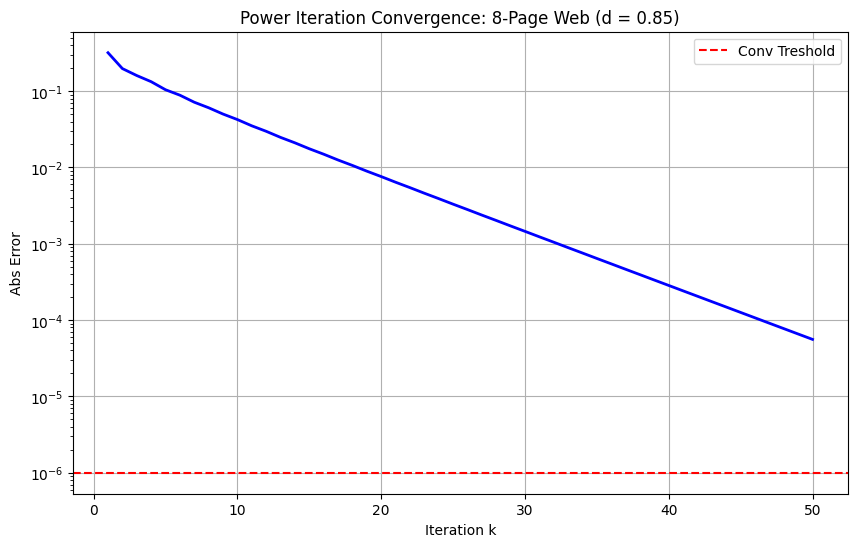

In [22]:
# Run Power Iteration
r_web_test, history_web_test = pagerank_power_iteration(m_prime_web, epsilon=1e-6)

print("\nPage | PageRank Score | Percentage")
print("-" * 42)
for label, score in zip(page_labels, r_web_test):
    print(f"  {label}  |    {score:.6f}    |   {score*100:.2f}%")
print("-" * 42)
print(f"Sum: {r_web_test.sum():.6f}")

# Plot convergence
plot_convergence(history_web_test, title="Power Iteration Convergence: 8-Page Web (d = 0.85)")

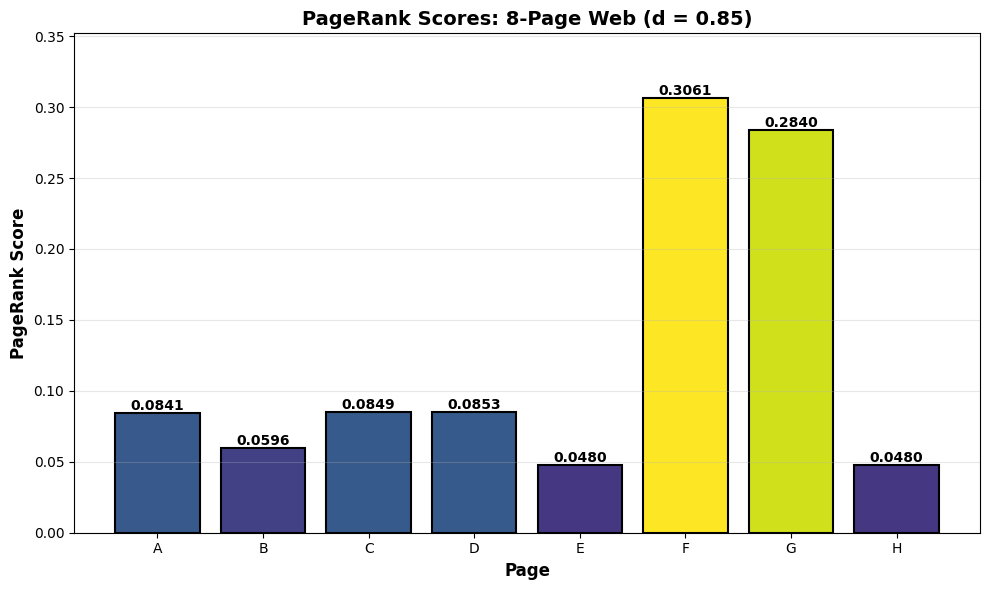

In [23]:
plot_pagerank_scores(r_web_test, page_labels, title="PageRank Scores: 8-Page Web (d = 0.85)")

## Eigenvector Validaiton

The applied approach is desscribed below:

1. First, we will find the eigenvector corresponding to eigenvalue $\lambda = 1$. This will be our basic version. We will compute all eigenvalues and eigenvectors. We ill generate an array of all eigenvalues and a matrix of eigenvectors where column i is eigenvector for eigenvalue i.
2. Second, we will normalize the eigenvector to sum up to 1 and will compare the result with power iteration. If the results from the power interations equals the eigenvalues then we can assume that the PageRank vector is correct.     
3. _Visualize_

### Numpy Eigenvalue Solver

In [24]:
def find_dominant_eigenvector_v1(m_prime): 
    eigenvalues, eigenvectors = np.linalg.eig(m_prime)

    print(f"First 5 eigenvalues: {eigenvalues[:5]}")  

    abs_eigenvalues = np.abs(eigenvalues - 1.0) #Returns how close is the eigenvalue is to 1.0
    idx_lambda_1 = np.argmin(abs_eigenvalues) #Returns indices of the smallest abs_eigenvalue => the eigenvalue closest to 1
    dominant_eigenvalue = eigenvalues[idx_lambda_1] #Exctract the dominat eigenvalue

    print(f"Dominant eigenvalue: λ₁ = {dominant_eigenvalue:.6f}") #Should be 1.0 for stochastic matrice

    eigenvector = eigenvectors [:, idx_lambda_1] #exctract the vector which is actually a column in the matrix
    eigenvector = np.abs(eigenvector.real) #remove the case when the eigenvalue is complex number
    print(f"Raw eigenvector: {eigenvector}")

    return eigenvector, dominant_eigenvalue

In [25]:
eig_vec_test, eig_val_test = find_dominant_eigenvector_v1(m_prime_test) 

print(f"\nEigenvector sum: {eig_vec_test.sum():.6f}") #Note: Not normalized to sum=1 yetb

First 5 eigenvalues: [ 1.   +0.j     -0.425+0.7361j -0.425-0.7361j]
Dominant eigenvalue: λ₁ = 1.000000+0.000000j
Raw eigenvector: [0.5774 0.5774 0.5774]

Eigenvector sum: 1.732051


In [26]:
eig_vec_test, eig_val_test = find_dominant_eigenvector_v1(m_prime_web)

print(f"\nEigenvector sum: {eig_vec_test.sum():.6f}") #Note: Not normalized to sum=1 yetb

First 5 eigenvalues: [ 1.    +0.j      0.7466+0.j     -0.85  +0.j     -0.2735+0.3936j
 -0.2735-0.3936j]
Dominant eigenvalue: λ₁ = 1.000000+0.000000j
Raw eigenvector: [0.1862 0.1319 0.188  0.1888 0.1063 0.6776 0.6287 0.1063]

Eigenvector sum: 2.213710


In [27]:
#Normalizing Pricnipal Eigenvector + Validate with Power Iteration Approach
def find_ev_and_validate(m_prime, pagerank_power_result): 
    eigenvalues, eigenvectors = np.linalg.eig(m_prime)
    
    idx_lambda_1 = np.argmin(np.abs(eigenvalues - 1.0)) #Returns indices of the smallest abs_eigenvalue => the eigenvalue closest to 1
    
    dominant_eigenvalue = eigenvalues[idx_lambda_1] #Exctract the dominat eigenvalue
    
    pagerank_eig = np.abs(eigenvectors[:,idx_lambda_1].real)
    pagerank_eig = pagerank_eig / pagerank_eig.sum() # Normalize to sum = 1. This step should make the probability distribution = Power Iteration result 

    validation_error = np.linalg.norm(
        pagerank_power_result - pagerank_eig, ord = 1 
)

    if validation_error < 1e-6: 
        print ("Validation Passed\n")
    else:
        print ("Validation Failed\n")

    return pagerank_eig, validation_error

In [28]:
# Get Power Iteration result - A_test network
r_test_pi, history_test_pi = pagerank_power_iteration(m_prime_test, epsilon = 1e-6)

#Validate with eigenvectors - A_test network
r_test_eig, error_test = find_ev_and_validate(m_prime_test, r_test_pi)

print("\nPage | Power Iter | Eigenvectors |  Change")
print("-"*60)
for i, label in enumerate(pages_test):
    change = np.abs(r_test_eig[i] - r_test_pi[i])
    print(f"  {label}  |  {r_test_pi[i]:.6f}  |    {r_test_eig[i]:.6f}  |  {(change):.4f}")


Iteration 1: error = 0.00e+00
Converged in 1 with final error = 0.00e+00

Validation Passed


Page | Power Iter | Eigenvectors |  Change
------------------------------------------------------------
  A  |  0.333333  |    0.333333  |  0.0000
  B  |  0.333333  |    0.333333  |  0.0000
  C  |  0.333333  |    0.333333  |  0.0000


Here the Validation is passed with the dafault value of the power iteration algorithm because of the webs' structure simplicity.  

In [29]:
# Get Power Iteration result - Full Network - No Damping Effect
r_web_pi, history_web_pi = pagerank_power_iteration(m_web, 1e-6, 50) #Change the max_iterations parameter for experimetns

#Validate with eigenvectors
r_web_eig, error_test = find_ev_and_validate(m_web, r_web_pi)

print("\nPage | Power Iter  | Eigenvectors  | Change")
print("-"*60)
for i, label in enumerate(page_labels):
    change = np.abs(r_web_eig[i] - r_web_pi[i])
    print(f"  {label}  |  {r_web_pi[i]:.6f}   |  {r_web_eig[i]:.6f}     |  {(change):.4f}")
print("-"*60)


Iteration 1: error = 3.75e-01
Iteration 26: error = 1.92e-01
Validation Failed


Page | Power Iter  | Eigenvectors  | Change
------------------------------------------------------------
  A  |  0.000228   |  0.000000     |  0.0002
  B  |  0.000144   |  0.000000     |  0.0001
  C  |  0.000226   |  0.000000     |  0.0002
  D  |  0.000225   |  0.000000     |  0.0002
  E  |  0.000099   |  0.000000     |  0.0001
  F  |  0.452346   |  0.500000     |  0.0477
  G  |  0.546633   |  0.500000     |  0.0466
  H  |  0.000099   |  0.000000     |  0.0001
------------------------------------------------------------


It is interestign to see what are the eigenvector values when no dumping effect is applied. The probability is distributed only between the pages F and G so the surfer can not escape the spider trap. While, the Power Iteration approach assign very small probabilities for the web surfer to visit pages different from F and G.

In [30]:
# Get Power Iteration result - Full Network - Dumping Effect
r_prime_web_pi, history_prime_web_pi = pagerank_power_iteration(m_prime_web, 1e-6, 100) #Change the max_iterations parameter for experimetns

#Validate with eigenvectors
r_prime_web_eig, error_prime_test = find_ev_and_validate(m_prime_web, r_web_pi)

print("\nPage | Power Iter  | Eigenvectors  | Change")
print("-"*60)
for i, label in enumerate(page_labels):
    change = np.abs(r_prime_web_eig[i] - r_prime_web_pi[i])
    print(f"  {label}  |  {r_prime_web_pi[i]:.6f}   |  {r_prime_web_eig[i]:.6f}     |  {(change):.4f}")
print("-"*60)


Iteration 1: error = 3.19e-01
Iteration 26: error = 2.81e-03
Iteration 51: error = 4.75e-05
Converged in 75 with final error = 9.60e-07

Validation Failed


Page | Power Iter  | Eigenvectors  | Change
------------------------------------------------------------
  A  |  0.084104   |  0.084104     |  0.0000
  B  |  0.059595   |  0.059595     |  0.0000
  C  |  0.084924   |  0.084924     |  0.0000
  D  |  0.085272   |  0.085272     |  0.0000
  E  |  0.048012   |  0.048012     |  0.0000
  F  |  0.306071   |  0.306071     |  0.0000
  G  |  0.284011   |  0.284011     |  0.0000
  H  |  0.048012   |  0.048012     |  0.0000
------------------------------------------------------------


Once we apply the dumping effect, then the performance is increasing significantly. The eigenvalues matches the power iterations output and distribute the probability to the other pages of the web. Even though the spider trap (pages F and G) still has the highest assigned importance, now the PageRank algorithm can assuem that a surfer will visit a different page randomly, so it needs to assign a corresponding value.     

We need to increase the max_iterations parameter to min 70 iterations for the power iterations function to converge. Otherwise the eigenvalues are not close enough to the PageRank vector resulted from the Power Iterations approach.     

In [31]:
def plot_validation_comparison(r_power, r_eig, labels):
    plt.figure(figsize=(12, 6))
    
    x = np.arange(len(labels)) # Bar positions
    width = 0.35
    
    bars1 = plt.bar(x - width/2, r_power, width, label='Power Iterns',
                    color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.8)
    bars2 = plt.bar(x + width/2, r_eig, width, label='Eigenvalue Decomp',
                    color='coral', edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Formatting
    plt.xlabel('Page', fontsize=12, fontweight='bold')
    plt.ylabel('PageRank Score', fontsize=12, fontweight='bold')
    plt.title('Validation: Power Iteration vs. Eigenvalue Decomposition', 
              fontsize=14, fontweight='bold')
    plt.xticks(x, labels)
    plt.grid(axis='y', alpha=0.3)
    
    # highlight difference
    for i, (p, e) in enumerate(zip(r_power, r_eig)):
        diff = abs(p - e)
        if diff > 1e-5:  # Only annotate if difference is visible
            plt.text(i, max(p, e) + 0.01, f'Δ={diff:.2e}',
                    ha='center', fontsize=8, color='red')
    
    plt.tight_layout()
    plt.show()

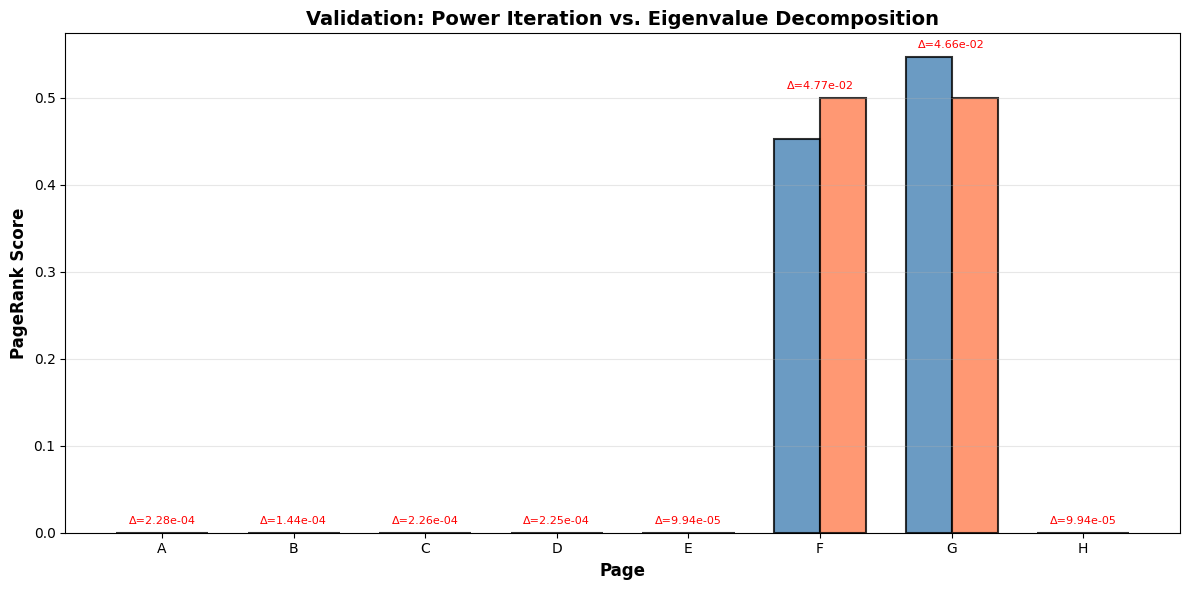

In [32]:
# Create comparison plot - no Dumping Effect
plot_validation_comparison(r_web_pi, r_web_eig, page_labels)

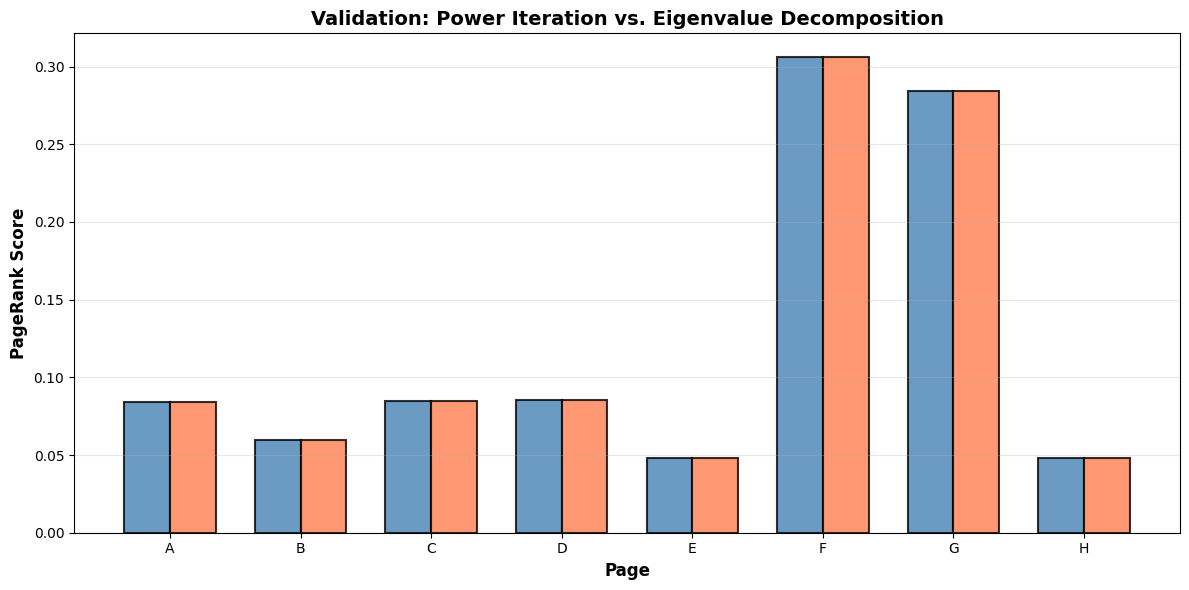

In [33]:
# Create comparison plot - Dumping Effect
plot_validation_comparison(r_prime_web_pi, r_prime_web_eig, page_labels)

## Edge Case and Damping Factor

In this section we will implement the damping factor to handle spider traps and ensure convergence. We will demonstrate why this is necessary and how different values affect results.

The applied approach is desscribed below:

1. First, we will investigate what happens when there is no teleportation and the web-surfer goes onli via linked pages. In such a case, the dampling factor $= 1.0$. This will demonstrate the spider trap problem
2. Second, we will apply the dampling factor that introduces random teleportation. The surfer follows a link with a probability $d$ and teleports (jump to a random page) with a probability $= (1-d)$.
3. Last, we will test different damping factors, analyze the effects on the final RangPage score and the convergence speed of the eigenvalues.
4. We will apply above three points using both Power Iteration and Eigenvector approaches to validate the performance of the eigenvectors approach.

In [34]:
#Demonstrate the Problem -> Test the PageRank scoring without dampling factor -> All probability ends up at the spider-trap
r_no_damp, hist_no_damp = pagerank_with_convergence(m_web, 1e-6, 100)

print("\nPage | PageRank Score | Percentage")
print("-"*42)
for label, score in zip(page_labels, r_no_damp):
    print(f"  {label}  |    {score:.6f}    |   {score*100:.2f}%")
print("-"*42)

print(f"  Pages F+G (spider trap): {(r_no_damp[5] + r_no_damp[6])*100:.1f}%")
print(f"  Main web (A-E): {((np.sum(r_no_damp) - r_no_damp[5] - r_no_damp[6]))*100:.1f}%")
print("\n  Spider trap captures most/all probability and main web gets near-zero importance.")

Iteration 1: error = 3.75e-01
Iteration 26: error = 1.92e-01
Iteration 51: error = 1.89e-01
Iteration 76: error = 1.89e-01

Page | PageRank Score | Percentage
------------------------------------------
  A  |    0.000000    |   0.00%
  B  |    0.000000    |   0.00%
  C  |    0.000000    |   0.00%
  D  |    0.000000    |   0.00%
  E  |    0.000000    |   0.00%
  F  |    0.452829    |   45.28%
  G  |    0.547169    |   54.72%
  H  |    0.000000    |   0.00%
------------------------------------------
  Pages F+G (spider trap): 100.0%
  Main web (A-E): 0.0%

  Spider trap captures most/all probability and main web gets near-zero importance.


In [35]:
#Add damping function (from Issue #7 preview) and full 8-page test:
def add_damping(transition_matrix, damping_factor = 0.85):
    n = transition_matrix.shape[0] #number of pages
    d = damping_factor 
    e = np.ones((n, n)) #nxn matrix of 1
    
    m_prime = d * transition_matrix + ((1 - d) / n) * e # apply the damping factor to the transition matrix ( M' = d * M + ((1-d) / n) * E)
    
    column_sums = m_prime.sum(axis=0) # Verify column-stochastic property is kept = 1.0
    assert np.allclose(column_sums, 1.0), "Error: Damped matrix is not column-stochastic"
    print(f"Damping factor d = {d} applied.")

    return m_prime

In [36]:
#Compare with and without damping - Power Iteration
m_prime_web # Transition Matrix with applied dumping effect

r_web_pi, history_web_pi # No Dumping Effect

r_prime_web_pi, history_prime_web_pi #With Damping Effect

print("\nPage | Without Damp | With Damp| Change")
print("-"*60)
for i, label in enumerate(page_labels):
    change = r_prime_web_pi[i] - r_web_pi[i]
    print(f"  {label}  |   {r_web_pi[i]:.6f}   | {r_prime_web_pi[i]:.6f} | {(change):.4f}")
print("-"*60)


Page | Without Damp | With Damp| Change
------------------------------------------------------------
  A  |   0.000228   | 0.084104 | 0.0839
  B  |   0.000144   | 0.059595 | 0.0595
  C  |   0.000226   | 0.084924 | 0.0847
  D  |   0.000225   | 0.085272 | 0.0850
  E  |   0.000099   | 0.048012 | 0.0479
  F  |   0.452346   | 0.306071 | -0.1463
  G  |   0.546633   | 0.284011 | -0.2626
  H  |   0.000099   | 0.048012 | 0.0479
------------------------------------------------------------


In [37]:
#Compare with and without damping - Eigenvectors

r_web_eig, error_test  #Run without dumping 
 
r_prime_web_eig, error_prime_test #Run with dumping

print("\nPage | Without Damp | WITH Damp | Change")
print("-"*60)
for i, label in enumerate(page_labels):
    change = r_prime_web_eig[i] - r_web_eig[i]
    print(f"  {label}  |   {r_web_eig[i]:.6f}   | {r_prime_web_eig[i]:.6f} | {(change):.4f}")
print("-"*60)


Page | Without Damp | WITH Damp | Change
------------------------------------------------------------
  A  |   0.000000   | 0.084104 | 0.0841
  B  |   0.000000   | 0.059595 | 0.0596
  C  |   0.000000   | 0.084924 | 0.0849
  D  |   0.000000   | 0.085272 | 0.0853
  E  |   0.000000   | 0.048012 | 0.0480
  F  |   0.500000   | 0.306071 | -0.1939
  G  |   0.500000   | 0.284011 | -0.2160
  H  |   0.000000   | 0.048012 | 0.0480
------------------------------------------------------------


In [38]:
# Test Damping Values - Power Iterations
damping_values = [0.25, 0.5, 0.75, 0.85, 0.95]

results_pi = {}

for d in damping_values:
    m_prime_web = add_damping(m_web, d) #apply damping

    r_pi, history_pi = pagerank_power_iteration(m_prime_web, 1e-6,100)

    iterations = len(history_prime_web_pi)
    results_pi[d] = (r_pi, iterations,history_pi) 

Damping factor d = 0.25 applied.
Iteration 1: error = 9.38e-02
Converged in 9 with final error = 8.25e-07

Damping factor d = 0.5 applied.
Iteration 1: error = 1.88e-01
Converged in 18 with final error = 7.56e-07

Damping factor d = 0.75 applied.
Iteration 1: error = 2.81e-01
Iteration 26: error = 1.08e-04
Converged in 43 with final error = 8.02e-07

Damping factor d = 0.85 applied.
Iteration 1: error = 3.19e-01
Iteration 26: error = 2.81e-03
Iteration 51: error = 4.75e-05
Converged in 75 with final error = 9.60e-07

Damping factor d = 0.95 applied.
Iteration 1: error = 3.56e-01
Iteration 26: error = 5.06e-02
Iteration 51: error = 1.38e-02
Iteration 76: error = 3.83e-03


In [39]:
print("\n  d  | Iterations | Spider Trap (F+G) | Main Web (A-E)")
print("-"*60)
for d in damping_values:
    r, iters, _ = results_pi[d]
    spider = (r[5] + r[6]) * 100
    main = (sum(r))* 100 - spider
    print(f" {d:.2f} |     {iters:3d}    |      {spider:5.1f}%      |     {main:5.1f}%")
print("-"*60)


  d  | Iterations | Spider Trap (F+G) | Main Web (A-E)
------------------------------------------------------------
 0.25 |      75    |       29.5%      |      70.5%
 0.50 |      75    |       36.1%      |      63.9%
 0.75 |      75    |       48.7%      |      51.3%
 0.85 |      75    |       59.0%      |      41.0%
 0.95 |      75    |       79.3%      |      20.7%
------------------------------------------------------------


In [40]:
# Test Damping Values - Eigenvectors
damping_values = [0.25, 0.5, 0.75, 0.85, 0.95]

results_eig = {}

for d in damping_values:
    m_prime_web = add_damping(m_web, d) #apply damping
    
    r_pi, history_pi = pagerank_power_iteration(m_prime_web, 1e-6, 100) #run for validation
    
    r_eig, history_eig = find_ev_and_validate(m_prime_web,r_pi)
    
    results_eig[d] = (r_eig, iterations, history_eig) 

Damping factor d = 0.25 applied.
Iteration 1: error = 9.38e-02
Converged in 9 with final error = 8.25e-07

Validation Passed

Damping factor d = 0.5 applied.
Iteration 1: error = 1.88e-01
Converged in 18 with final error = 7.56e-07

Validation Passed

Damping factor d = 0.75 applied.
Iteration 1: error = 2.81e-01
Iteration 26: error = 1.08e-04
Converged in 43 with final error = 8.02e-07

Validation Passed

Damping factor d = 0.85 applied.
Iteration 1: error = 3.19e-01
Iteration 26: error = 2.81e-03
Iteration 51: error = 4.75e-05
Converged in 75 with final error = 9.60e-07

Validation Passed

Damping factor d = 0.95 applied.
Iteration 1: error = 3.56e-01
Iteration 26: error = 5.06e-02
Iteration 51: error = 1.38e-02
Iteration 76: error = 3.83e-03
Validation Failed



In [41]:
print("\n  d  | Iterations | Spider Trap (F+G) | Main Web (A-E)")
print("-"*60)
for d in damping_values:
    r, iters, _ = results_eig[d]
    spider = (r[5] + r[6]) * 100
    main = (sum(r))* 100 - spider
    print(f" {d:.2f} |     {iters:3d}    |      {spider:5.1f}%      |     {main:5.1f}%")
print("-"*60)


  d  | Iterations | Spider Trap (F+G) | Main Web (A-E)
------------------------------------------------------------
 0.25 |      75    |       29.5%      |      70.5%
 0.50 |      75    |       36.1%      |      63.9%
 0.75 |      75    |       48.7%      |      51.3%
 0.85 |      75    |       59.0%      |      41.0%
 0.95 |      75    |       79.3%      |      20.7%
------------------------------------------------------------


Summary: 

* Lower $d = 0.50$: Fast convergence, more uniform distribution.
* Higher $d = 0.95$: Slow convergence, more emphasis on link structure.
* Standard $d = 0.85$: Good balance between accuracy and speed.
* We use the same values when applying the PI Algorithm and the Eigenvectors as expected
   

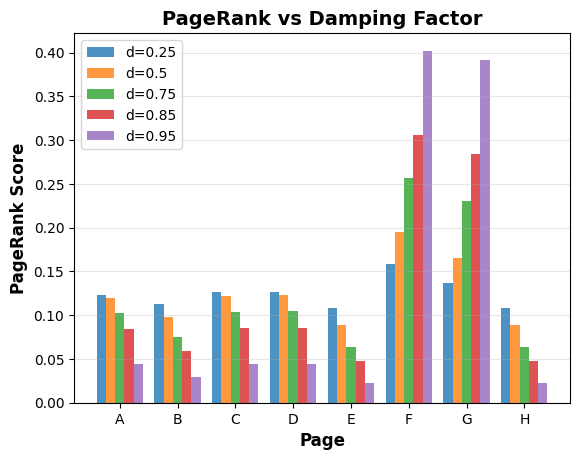

In [44]:
fig = plt.plot(figsize=(15, 6))
    
# Plot 1: PageRank scores comparison
damping_values = sorted(results_eig.keys())
x = np.arange(len(page_labels))
width = 0.8 / len(damping_values)
    
for i, d in enumerate(damping_values):
    r, _, _ = results_eig[d]
    offset = (i - len(damping_values)/2) * width + width/2
    plt.bar(x + offset, r, width, label=f'd={d}', alpha=0.8)
    
plt.xlabel('Page', fontsize=12, fontweight='bold')
plt.ylabel('PageRank Score', fontsize=12, fontweight='bold')
plt.title('PageRank vs Damping Factor', fontsize=14, fontweight='bold')
plt.xticks(x, page_labels)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

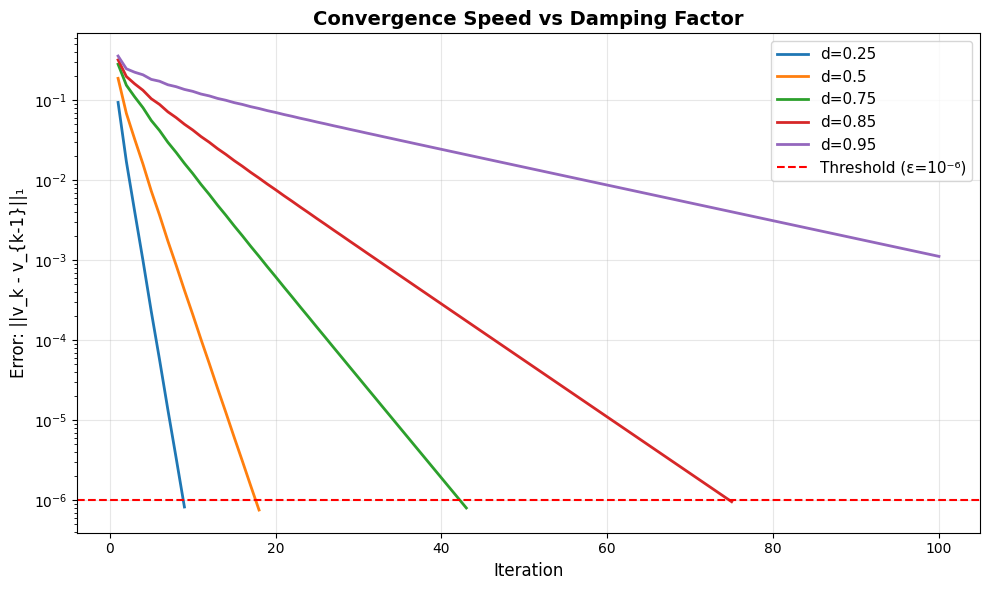

In [54]:
# Additional: Show convergence curves for different d values
fig = plt.figure(figsize=(10, 6))
for d in damping_values:
    _, _, history_pi = results_pi[d]
    plt.semilogy(range(1, len(history_pi)+1), history_pi, label=f'd={d}', linewidth=2)

plt.axhline(y=1e-6, color='r', linestyle='--', label='Threshold (ε=10⁻⁶)')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Error: ||v_k - v_{k-1}||₁', fontsize=12)
plt.title('Convergence Speed vs Damping Factor', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()